# Sinusoidal plus Residual (SPS) Model Example

This notebook demonstrates the **SPS Model**, which separates a sound into a sinusoidal component and a residual component. The steps include:
1. Import required libraries
2. Load and visualize the audio signal
3. Compute and display the STFT
4. Analyze the sinusoidal model
5. Detect peaks in spectra
6. Synthesize the sinusoidal component
7. Extract and synthesize the residual
8. Visualize sinusoidal tracks

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import utilFunctions as UF
from smstools.models import sineModel as SINE
from smstools.models import stft as STFT
from smstools.models import spsModel as SPS
import plot_helpers as PH

PH.setup_plot_style()

## 1) Load and Visualize Audio Signal

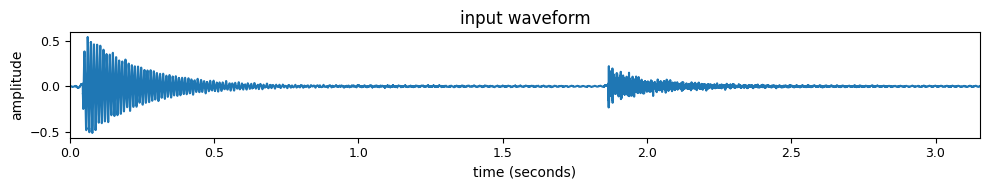

In [8]:
input_file = '../sounds/bendir.wav'  # Change to your audio file if needed
fs, x = UF.wavread(input_file)

fig, ax = plt.subplots(figsize=(10, 2))
PH.plot_waveform(ax, x, fs, title='input waveform', xlabel='time (seconds)')
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data=x, rate=fs))

## 2) SPS Model Analysis and Synthesis

This section analyzes the signal using the SPS model, synthesizes the sinusoidal and residual components, and displays the full output.

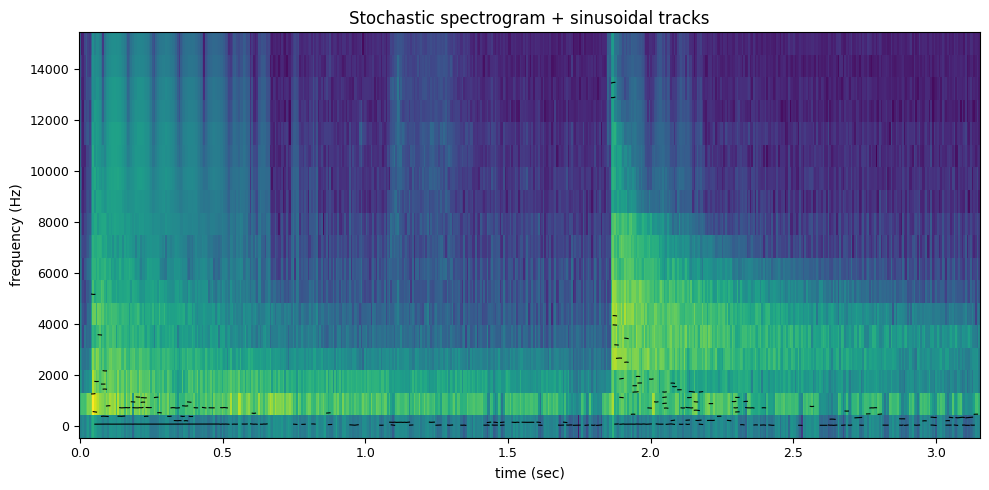

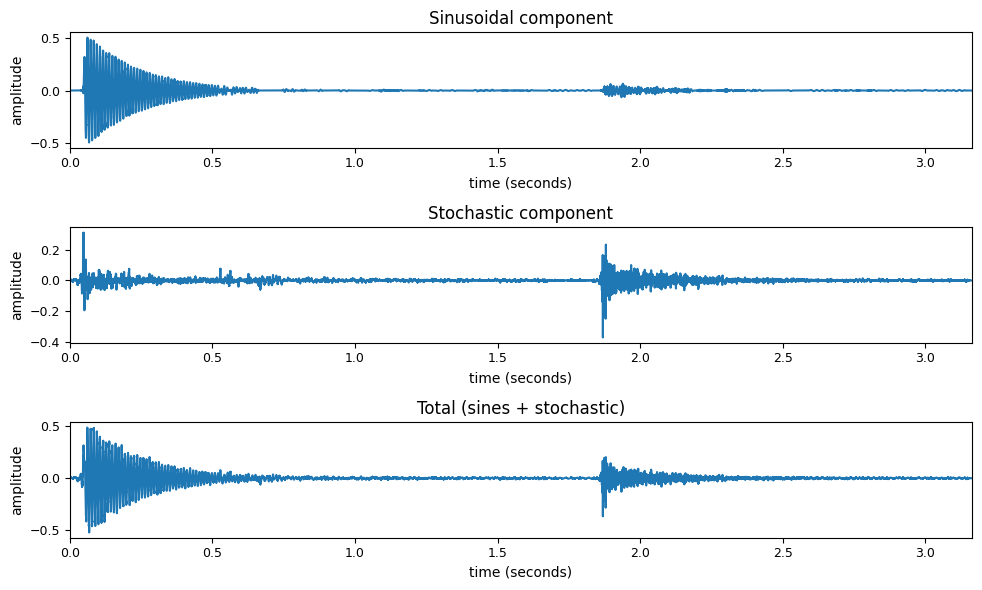

In [9]:
# SPS model analysis and synthesis (sinusoidal + stochastic)
window = 'blackman'  # window type
M = 1024             # window size
N = 2048             # FFT size
H = 256              # hop size
t = -80              # threshold (dB)
w = get_window(window, M)

stocf = 0.1  # stochastic factor (adjust as needed)
minSineDur = 0.02
maxnSines = 150
freqDevOffset = 10
freqDevSlope = 0.001
Ns = 512  # FFT size for synthesis

# Perform sinusoidal + stochastic analysis
tfreq, tmag, tphase, stocEnv = SPS.spsModelAnal(
    x, fs, w, N, H, t, minSineDur, maxnSines, freqDevOffset, freqDevSlope, stocf
)

# Synthesize sinusoidal + stochastic model
y, ys, yst = SPS.spsModelSynth(tfreq, tmag, tphase, stocEnv, Ns, H, fs)

# Plot stochastic spectrogram with sinusoidal tracks overlay
fig, ax = plt.subplots(figsize=(10, 5))
PH.plot_spectrogram_with_tracks(ax, stocEnv, tfreq, fs, 2 * stocEnv.shape[1], H, max_plot_freq=15000.0, title='Stochastic spectrogram + sinusoidal tracks')
plt.tight_layout()
plt.show()

# Plot the three components: sines, stochastic, total
fig2, axs2 = plt.subplots(3, 1, figsize=(10, 6))
PH.plot_waveform(axs2[0], ys, fs, title='Sinusoidal component', xlabel='time (seconds)')
PH.plot_waveform(axs2[1], yst, fs, title='Stochastic component', xlabel='time (seconds)')
PH.plot_waveform(axs2[2], y, fs, title='Total (sines + stochastic)', xlabel='time (seconds)')
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data=ys, rate=fs))
ipd.display(ipd.Audio(data=yst, rate=fs))
ipd.display(ipd.Audio(data=y, rate=fs))